In [4]:
!pip install -q transformers datasets peft bitsandbytes accelerate trl
print("✅ Cài xong!")

✅ Cài xong!


## 🔑 Bước 1 — Đăng nhập HuggingFace

In [5]:
from huggingface_hub import login

login()
print("✅ Đăng nhập thành công!")

✅ Đăng nhập thành công!


## 📦 Bước 2 — Import thư viện

In [6]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, roc_auc_score,
    confusion_matrix, roc_curve,
)

# Kiểm tra GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Không có GPU! Vào Runtime → Change runtime type → T4 GPU")

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## ⚙️ Bước 3 — Cấu hình
Có thể điều chỉnh các thông số ở đây nếu cần

In [7]:
# ── Model ───────────────────────────────────────
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"

# ── Dataset ──────────────────────────────────────
TRAIN_PATH = "train.csv"
VAL_PATH   = "val.csv"
TEST_PATH  = "test.csv"

# ── Tokenizer ────────────────────────────────────
MAX_LENGTH = 512  # số token tối đa mỗi bài (512 là đủ cho hầu hết bài báo)

# ── LoRA ─────────────────────────────────────────
LORA_R       = 8    # rank — càng cao càng mạnh nhưng tốn VRAM hơn
LORA_ALPHA   = 16   # scaling factor (thường = 2 x LORA_R)
LORA_DROPOUT = 0.05

# ── Training ─────────────────────────────────────
BATCH_SIZE  = 8   # giảm xuống 4 nếu bị lỗi OOM (hết VRAM)
NUM_EPOCHS  = 3
LR          = 2e-4

# ── Labels ───────────────────────────────────────
LABEL2ID = {"REAL": 0, "FAKE": 1}
ID2LABEL = {0: "REAL", 1: "FAKE"}

print("✅ Cấu hình xong!")
print(f"  Model      : {MODEL_NAME}")
print(f"  Max tokens : {MAX_LENGTH}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {BATCH_SIZE} (x4 grad accum = effective {BATCH_SIZE*4})")

✅ Cấu hình xong!
  Model      : meta-llama/Llama-3.2-1B-Instruct
  Max tokens : 512
  Epochs     : 3
  Batch size : 8 (x4 grad accum = effective 32)


## 📂 Bước 4 — Đọc dữ liệu

In [8]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

def prepare_df(df):
    df = df[["text", "label", "label_id"]].copy()
    df["text"] = df["text"].fillna("").astype(str)
    return df

train_df = prepare_df(train_df)
val_df   = prepare_df(val_df)
test_df  = prepare_df(test_df)

print(f"Train : {len(train_df):,} rows | {train_df['label'].value_counts().to_dict()}")
print(f"Val   : {len(val_df):,} rows  | {val_df['label'].value_counts().to_dict()}")
print(f"Test  : {len(test_df):,} rows  | {test_df['label'].value_counts().to_dict()}")

# Chuyển sang HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)
print("✅ Đọc dữ liệu xong!")

Train : 10,417 rows | {'REAL': 6747, 'FAKE': 3670}
Val   : 2,232 rows  | {'REAL': 1446, 'FAKE': 786}
Test  : 2,233 rows  | {'REAL': 1446, 'FAKE': 787}
✅ Đọc dữ liệu xong!


## 🔤 Bước 5 — Load Tokenizer & Tokenize
Tokenizer của LLaMA sẽ chuyển văn bản thành dãy số (token IDs) mà model có thể hiểu được

In [9]:
print("Đang load tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)

# LLaMA không có padding token mặc định → thêm vào
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
print("✅ Load tokenizer xong!")

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

print("Đang tokenize dataset (mất 1-2 phút)...")
train_tok = train_dataset.map(tokenize_fn, batched=True, remove_columns=["text", "label"])
val_tok   = val_dataset.map(tokenize_fn,   batched=True, remove_columns=["text", "label"])
test_tok  = test_dataset.map(tokenize_fn,  batched=True, remove_columns=["text", "label"])

# Đổi tên cột label cho Trainer
train_tok = train_tok.rename_column("label_id", "labels")
val_tok   = val_tok.rename_column("label_id", "labels")
test_tok  = test_tok.rename_column("label_id", "labels")

train_tok.set_format("torch")
val_tok.set_format("torch")
test_tok.set_format("torch")
print("✅ Tokenize xong!")

Đang load tokenizer...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

✅ Load tokenizer xong!
Đang tokenize dataset (mất 1-2 phút)...


Map:   0%|          | 0/10417 [00:00<?, ? examples/s]

Map:   0%|          | 0/2232 [00:00<?, ? examples/s]

Map:   0%|          | 0/2233 [00:00<?, ? examples/s]

✅ Tokenize xong!


## 🧠 Bước 6 — Load Model + QLoRA

**QLoRA hoạt động như thế nào?**
1. Load model LLaMA ở dạng **4-bit** (thay vì 32-bit thông thường) → tiết kiệm ~8x VRAM
2. Thêm các **LoRA adapters** nhỏ vào các lớp attention
3. Chỉ train adapters (~1% tham số) thay vì toàn bộ model → nhanh hơn nhiều

In [10]:
print("Đang load model LLaMA (mất 2-5 phút, tải ~2GB)...")

# Cấu hình 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",               # NormalFloat4 — tốt nhất cho LLM
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,           # tiết kiệm thêm ~0.4 bits/param
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model.config.pad_token_id = tokenizer.pad_token_id
print("✅ Load model xong!")

# Chuẩn bị model cho QLoRA training
model = prepare_model_for_kbit_training(model)

# Thêm LoRA adapters
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "v_proj"],  # áp dụng lên attention layers
    bias="none",
)
model = get_peft_model(model, lora_config)

print("\n📊 Số tham số:")
model.print_trainable_parameters()
# → Kỳ vọng: ~0.5-1% tham số được train (rất nhỏ so với toàn bộ model)

Đang load model LLaMA (mất 2-5 phút, tải ~2GB)...


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Load model xong!

📊 Số tham số:
trainable params: 856,064 || all params: 1,236,674,560 || trainable%: 0.0692


## 🏋️ Bước 7 — Training
Training với 3 epochs, mỗi epoch evaluate trên val set để theo dõi tiến trình

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    proba = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "roc_auc" : roc_auc_score(labels, proba),
    }

training_args = TrainingArguments(
    output_dir="./llama_checkpoints",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=4,   # effective batch = BATCH_SIZE x 4
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",                 # tắt wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("🚀 Bắt đầu training LLaMA với QLoRA...")
print(f"   Tổng steps ≈ {len(train_tok) // (BATCH_SIZE * 4) * NUM_EPOCHS} steps")
trainer.train()
print("✅ Training xong!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


🚀 Bắt đầu training LLaMA với QLoRA...
   Tổng steps ≈ 975 steps


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Roc Auc
1,0.583035,0.155861,0.955197,0.949597,0.993789
2,0.261733,0.067897,0.977151,0.974790,0.997777
3,0.162840,0.080142,0.978047,0.975880,0.997337


✅ Training xong!


## 📊 Bước 8 — Đánh giá trên Test set

In [12]:
predictions = trainer.predict(test_tok)
logits  = predictions.predictions
y_pred  = np.argmax(logits, axis=-1)
y_proba = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
y_true  = predictions.label_ids

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)
f1  = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print(f"Test F1-macro : {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["REAL", "FAKE"]))

Test Accuracy : 0.9767
Test ROC-AUC  : 0.9971
Test F1-macro : 0.9745

              precision    recall  f1-score   support

        REAL       0.98      0.98      0.98      1446
        FAKE       0.96      0.97      0.97       787

    accuracy                           0.98      2233
   macro avg       0.97      0.98      0.97      2233
weighted avg       0.98      0.98      0.98      2233



## 📈 Bước 9 — Vẽ biểu đồ

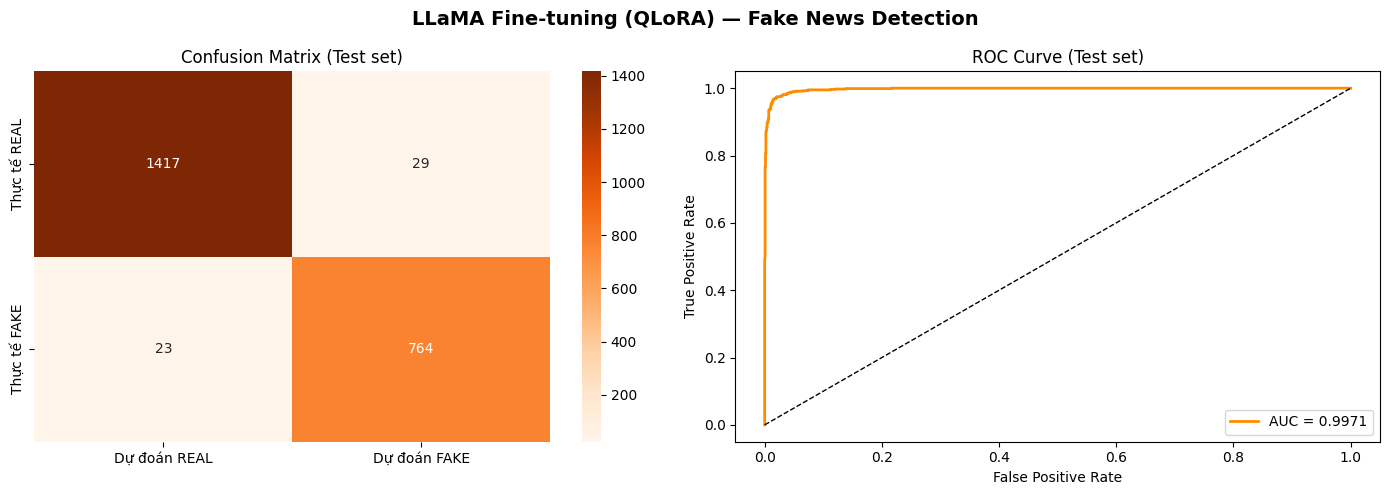

✅ Biểu đồ đã lưu: llama_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LLaMA Fine-tuning (QLoRA) — Fake News Detection", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Dự đoán REAL", "Dự đoán FAKE"],
            yticklabels=["Thực tế REAL", "Thực tế FAKE"], ax=axes[0])
axes[0].set_title("Confusion Matrix (Test set)")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_proba)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test set)")
axes[1].legend()

plt.tight_layout()
plt.savefig("llama_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Biểu đồ đã lưu: llama_results.png")

## 💾 Bước 10 — Lưu model & Dự đoán bài mới

In [14]:
# Lưu LoRA adapter (nhỏ hơn rất nhiều so với full model)
model.save_pretrained("./llama_fakenews_adapter")
tokenizer.save_pretrained("./llama_fakenews_adapter")
print("✅ Đã lưu adapter tại: ./llama_fakenews_adapter")

# ── Hàm dự đoán bài mới ──────────────────────────────
def predict_article(title: str, content: str) -> None:
    text = title + " " + content
    inputs = tokenizer(
        text, return_tensors="pt",
        padding=True, truncation=True,
        max_length=MAX_LENGTH,
    ).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    proba = torch.softmax(outputs.logits, dim=-1)[0]
    pred  = torch.argmax(proba).item()
    label = "FAKE 🚨" if pred == 1 else "REAL ✅"
    print(f"{label}  (REAL: {proba[0]*100:.1f}% | FAKE: {proba[1]*100:.1f}%)")
    print(f"Tiêu đề: {title[:80]}")

# Demo
predict_article(
    "WHO xác nhận vaccine COVID-19 an toàn và hiệu quả",
    "Tổ chức Y tế Thế giới công bố báo cáo vaccine ngăn ngừa tử vong."
)
print()
predict_article(
    "TIẾT LỘ SỐC: Uống nước chanh chữa ung thư 100%!!!",
    "Bí quyết từ thầy lang bí ẩn ở Tây Nguyên được giấu kín hàng chục năm."
)

✅ Đã lưu adapter tại: ./llama_fakenews_adapter
REAL ✅  (REAL: 99.4% | FAKE: 0.6%)
Tiêu đề: WHO xác nhận vaccine COVID-19 an toàn và hiệu quả

FAKE 🚨  (REAL: 0.0% | FAKE: 100.0%)
Tiêu đề: TIẾT LỘ SỐC: Uống nước chanh chữa ung thư 100%!!!


In [15]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "./llama_fakenews_adapter",
    "/content/drive/MyDrive/llama_fakenews_adapter"
)
print("✅ Đã upload lên Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã upload lên Google Drive!


In [16]:
import shutil

shutil.copytree(
    "./llama_checkpoints",
    "/content/drive/MyDrive/llama_checkpoints"
)
print("✅ Đã upload checkpoints lên Drive!")

✅ Đã upload checkpoints lên Drive!


In [17]:
# Merge LoRA vào base model rồi lưu full
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./llama_merged")
tokenizer.save_pretrained("./llama_merged")

# Copy lên Drive
shutil.copytree(
    "./llama_merged",
    "/content/drive/MyDrive/llama_merged"
)
print("✅ Xong!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Xong!


In [20]:
import shutil, os

# Copy 2 file còn thiếu lên Drive
shutil.copy(
    "./llama_checkpoints/checkpoint-978/training_args.bin",
    "/content/drive/MyDrive/llama_merged/training_args.bin"
)

# special_tokens_map thường nằm trong tokenizer
tokenizer.save_pretrained("./llama_merged_v2")
# Rồi check xem có special_tokens_map.json không
files = os.listdir("./llama_merged_v2")
print(files)

['tokenizer.json', 'chat_template.jinja', 'tokenizer_config.json']


In [22]:
import os
print(os.listdir("./llama_checkpoints/checkpoint-978"))

['README.md', 'optimizer.pt', 'scheduler.pt', 'tokenizer.json', 'chat_template.jinja', 'training_args.bin', 'adapter_model.safetensors', 'trainer_state.json', 'tokenizer_config.json', 'rng_state.pth', 'scaler.pt', 'adapter_config.json']
